In [1]:
# Import json two Json files for initial and final data
import json
from datetime import datetime

In [2]:
import math
import numpy as np
from typing import List, Tuple, Dict

def generate_map_fixed(
    # Map bounds
    map_x_min: float, map_x_max: float,
    map_y_min: float, map_y_max: float,
    # Buildings: list of (x_vertices, y_vertices)
    building_xs: List[List[float]],
    building_ys: List[List[float]],
    # Camera positions and initial angles
    cam_x: List[float],
    cam_y: List[float],
    cam_init_angles: List[float],          # radians, one per camera
    n_direc: int,                          # how many are directional
    n_omni: int,                           # how many are omnidirectional
    # FOV
    fov_half_rad: float = math.radians(27.1),
    max_range: float = 500.0,
    fov_half_rad_omni: float = math.radians(180.0),
    max_range_omni: float = 500.0,
    # Panning
    bound_plus: float  = math.radians(85.0),
    bound_minus: float = math.radians(-85.0),
    panspeed_range: Tuple[float,float] = (math.radians(-360/1600), math.radians(360/1600)),
    cam_period: int = 200,
    cam_increment: float = 0.25,
    # Detection model
    param_lambda: List[float] = [0.5, 0.5],
    param_beta:   List[float] = [5, 5],
    rng_seed: int = 0,
) -> Tuple[Dict, Dict]:

    import random
    rng = random.Random(rng_seed)

    # ── map_in ────────────────────────────────────────────────
    st = {
        "size": np.array([map_x_min, map_x_max, map_y_min, map_y_max], dtype=float),
        "n": len(building_xs)
    }
    for i, (bx, by) in enumerate(zip(building_xs, building_ys)):
        st[str(i)] = np.array(list(zip(bx, by)), dtype=float)

    map_in = {
        "st": st,
        "n": int(cam_period),
        "ncam": n_direc + n_omni
    }

    # ── cam_dict ──────────────────────────────────────────────
    xs_direc = cam_x[:n_direc]
    ys_direc = cam_y[:n_direc]
    xs_omni  = cam_x[n_direc:n_direc+n_omni]
    ys_omni  = cam_y[n_direc:n_direc+n_omni]

    bounds = [[bound_plus, bound_minus] for _ in range(n_direc)]
    panspeeds = [float(rng.uniform(*panspeed_range)) for _ in range(n_direc + n_omni)]

    cam_dict = {
        "n": n_direc + n_omni,
        "n_direc": n_direc,
        "n_omni": n_omni,
        "directional": {
            "x": np.array(xs_direc, dtype=float),
            "y": np.array(ys_direc, dtype=float),
            "spec": {
                "init_angle": cam_init_angles[:n_direc],
                "bound": np.array(bounds, dtype=float),
                "fov": [float(fov_half_rad), float(max_range)],
                "cam_time": [int(cam_period), float(cam_increment)],
                "panspeed": panspeeds[:n_direc]
            }
        },
        "omnidirectional": {
            "x": np.array(xs_omni, dtype=float),
            "y": np.array(ys_omni, dtype=float),
            "spec": {
                "fov": [float(fov_half_rad_omni), float(max_range_omni)],
            }
        },
        "detection": {
            "directional":    {"param_lambda": param_lambda[0], "param_beta": param_beta[0]},
            "omnidirectional": {"param_lambda": param_lambda[1], "param_beta": param_beta[1]}
        }
    }

    return map_in, cam_dict

In [3]:
# Coordinate shift applied: x += 569.2, y += 6960
# Bottom-left corner is now the origin (0, 0)

# Map Size
map_x_min = 0
map_x_max = 6264.2
map_y_min = 0
map_y_max = 6815.4

# Building 1
b1_x = [165.9, 649.1, 632.1, 126.0]
b1_y = [3137.1, 3111.6, 2030.7, 2034.5]

# Building 2
b2_x = [3082.3, 3569.6, 3552.8, 3038.5]
b2_y = [1901.9, 1879.8, 177.8, 188.3]

# Building 3
b3_x = [5036.3, 5506.0, 5490.7, 4997.3]
b3_y = [4093.7, 4075.7, 3158.9, 3168.7]

# Building 4
b4_x = [2955.9, 4371.6, 4375.2, 2956.4]
b4_y = [5532.8, 5502.9, 5024.6, 5042.3]

# Camera Positions
# cam_x = [835.625, 3807.3, 2810.8]
# cam_y = [2558.6, 1014.975, 5665.475]

# This is Initial
# cam_x = [835.625, 3807.3, 4500]
# cam_y = [2558.6, 1014.975, 4800]

cam_x = [835.625, 3807.3, 3000]
cam_y = [2558.6, 1014.975, 4800]

In [4]:
def point_to_segment_dist(p, a, b):
    ab = b - a
    ap = p - a
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0, 1)
    closest = a + t * ab
    return np.linalg.norm(p - closest)

def compute_d_buff(sensor_pos, bx, by):
    """Minimum distance from sensor to all edges of a building."""
    verts = np.array(list(zip(bx, by)))
    n = len(verts)
    min_dist = float('inf')
    for i in range(n):
        a, b = verts[i], verts[(i+1) % n]
        d = point_to_segment_dist(np.array(sensor_pos), a, b)
        if d < min_dist:
            min_dist = d
    return min_dist

def make_buffered_rectangle(bx, by, d_buff):
    """
    Returns a new rectangular building that is the axis-aligned
    bounding box of the original building expanded outward by d_buff.
    Output: (new_bx, new_by) as lists of 4 corners (CCW order).
    """
    x_min = min(bx) - d_buff
    x_max = max(bx) + d_buff
    y_min = min(by) - d_buff
    y_max = max(by) + d_buff

    # Rectangle corners in CCW order
    new_bx = [x_min, x_max, x_max, x_min]
    new_by = [y_min, y_min, y_max, y_max]
    return new_bx, new_by


s1 = [cam_x[0], cam_y[0]]  # Sensor position (first camera)

d_buff = compute_d_buff(s1, b1_x, b1_y)
print(f"d_buff = {d_buff:.4f}")

new_b1_x, new_b1_y = make_buffered_rectangle(b1_x, b1_y, d_buff)
new_b2_x, new_b2_y = make_buffered_rectangle(b2_x, b2_y, d_buff)
new_b3_x, new_b3_y = make_buffered_rectangle(b3_x, b3_y, d_buff)
new_b4_x, new_b4_y = make_buffered_rectangle(b4_x, b4_y, d_buff)
# print(f"Buffered rectangle x: {new_bx}")
# print(f"Buffered rectangle y: {new_by}")

cam_init_angles = [np.deg2rad(0), np.deg2rad(90), np.deg2rad(180)]
n_direc = 3
n_omni = 0
fov_half_rad = math.radians(28.0)
sensor_range = 5000.0

map_in, cam_dict = generate_map_fixed(
    map_x_min=map_x_min, map_x_max=map_x_max,
    map_y_min=map_y_min,  map_y_max=map_y_max,
    building_xs=[new_b1_x, new_b2_x, new_b3_x, new_b4_x],
    building_ys=[new_b1_y, new_b2_y, new_b3_y, new_b4_y],
    cam_x=cam_x,
    cam_y=cam_y,
    cam_init_angles=cam_init_angles,
    n_direc=n_direc,
    n_omni=n_omni,
    fov_half_rad=fov_half_rad,
    max_range=sensor_range,
)

map_size = map_in['st']['size']

d_buff = 195.1982


In [5]:
# Import Json file 20260316_153002_Initial as initial_data
with open('20260316_153002_Initial.json', 'r') as f:
    initial_data = json.load(f)

with open('20260316_152209_Final.json', 'r') as f:
    final_data = json.load(f)

In [6]:
print(final_data.keys())

dict_keys(['attacker_initial_path', 'attacker_final_path', 'defender_setup', 'defender_cost_history', 'attacker_cost_history'])


In [7]:
initial_path = initial_data['attacker_initial_path']
final_path = final_data['attacker_final_path']
initial_setup = initial_data['defender_setup']
final_setup = final_data['defender_setup']

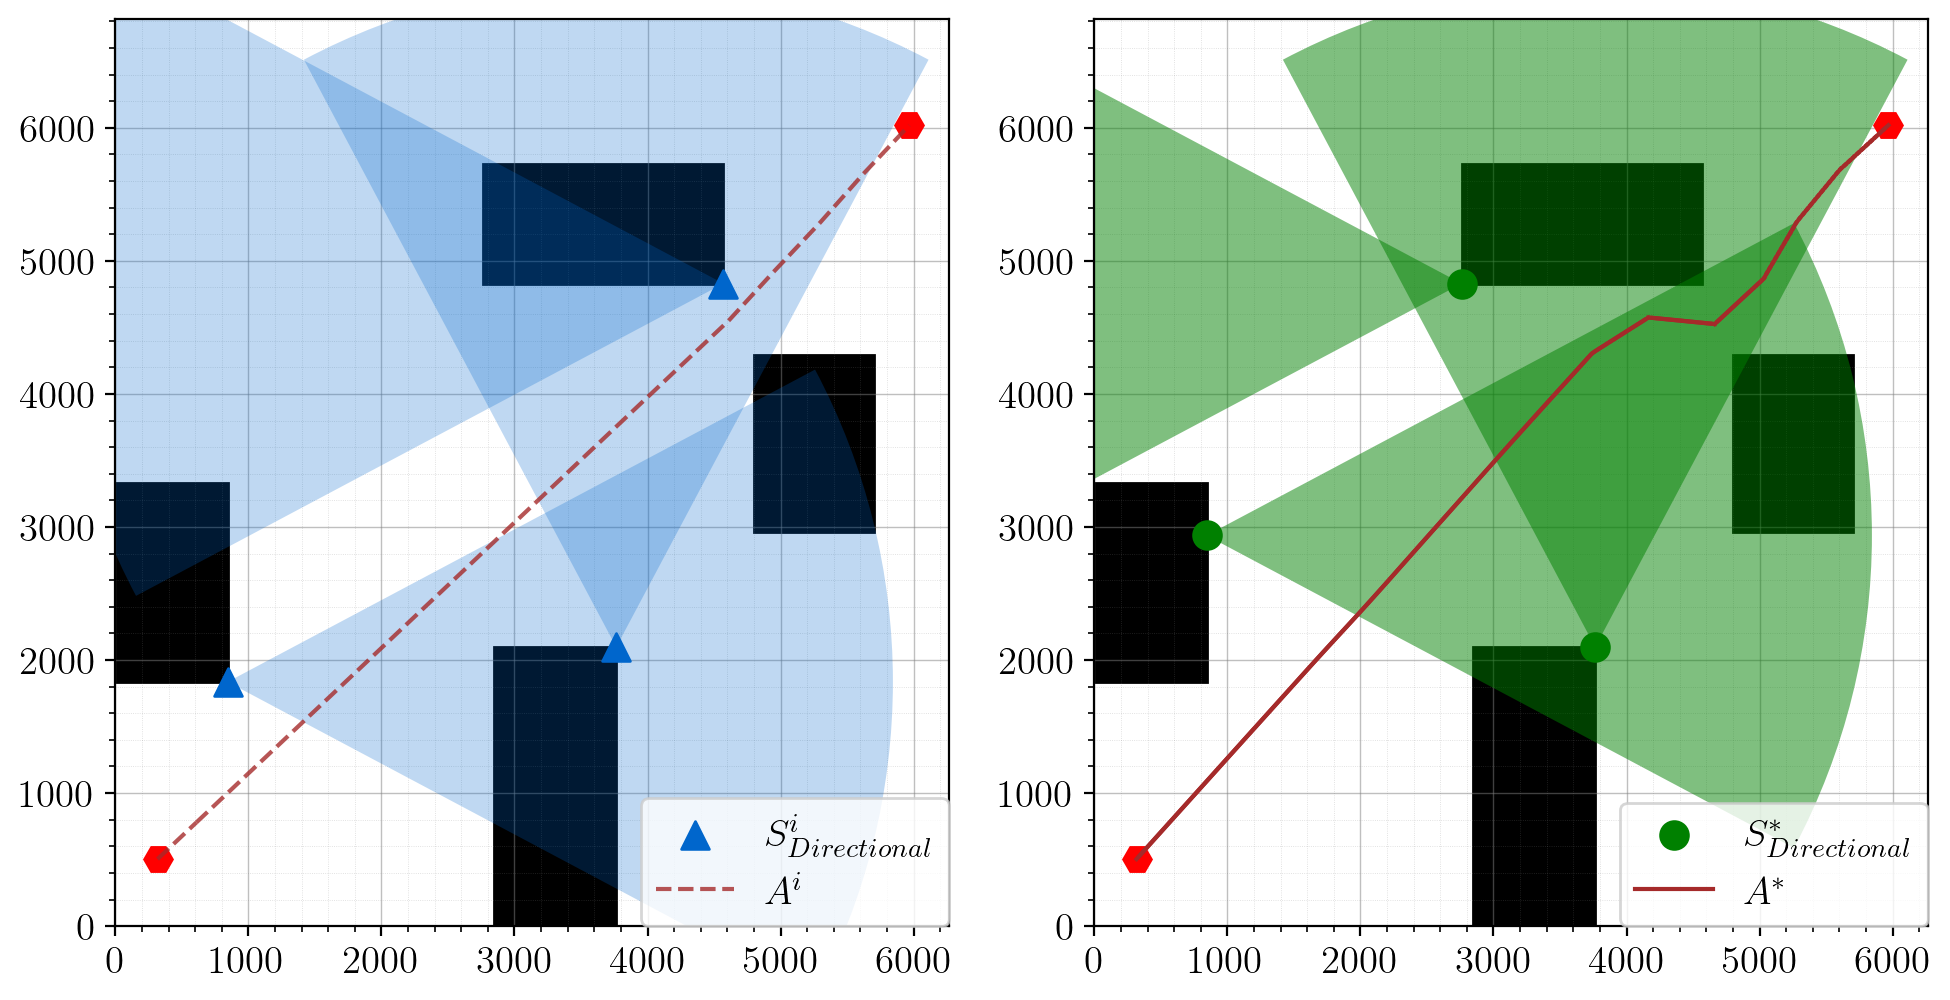

In [12]:
# Plot initial, final path and initial, final setup in a single plot
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True
marker_size_for_sensor = 100

# Start and Goal
x_init = [-252.075, -6456.2]
x_goal = [5399, -940.7]
x0 = [x_init[0] + 569.2,  x_init[1] + 6960,  0.0]
xf = [x_goal[0] + 569.2,  x_goal[1] + 6960,  60.0]
vmax = 500

# Parse Attacker strategy
att_optimal_x = final_path[0]
att_optimal_y = final_path[1]
att_optimal_t = final_path[2]

# Initial Defender strategy
cx_init = np.array(initial_setup[0], dtype=float)
cy_init = np.array(initial_setup[1], dtype=float)

# Parse Defender strategy
def_optimal_x = final_setup[0]
def_optimal_y = final_setup[1]

# ---- Static map bounds & buildings ----
st = map_in["st"]
size = np.array(st["size"], dtype=float)
xmin, xmax, ymin, ymax = size

buildings = []
for i in range(st["n"]):
    poly = np.array(st[str(i)], dtype=float)
    buildings.append(poly)

# ---- Cameras & spec ----
num_direc_sensor = 3
cx_opt = np.array(def_optimal_x[0:num_direc_sensor], dtype=float)
cy_opt = np.array(def_optimal_y[0:num_direc_sensor], dtype=float)
spec = cam_dict['directional']["spec"]
init_angles = np.array(spec["init_angle"], dtype=float)
bound_arr = np.array(spec["bound"], dtype=float)
fov_half = float(spec["fov"][0])
fov_range = float(spec["fov"][1])
panspeeds = np.array(spec["panspeed"], dtype=float)

t = 0
# facings = np.array([
#     _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
#     for i in range(num_direc_sensor)
# ], dtype=float)
facings = [0, np.pi/2, np.pi]

sensor_alpha = 0.5

fig, (ax_init, ax_opt) = plt.subplots(1, 2, figsize=(10, 8), dpi=200)

for ax in (ax_init, ax_opt):
    # Buildings
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))
    # Start / Goal
    ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
    ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth='0.3', color='gray', alpha=0.3)

# ==============================================================
# LEFT: Initial strategies
# ==============================================================
# Initial directional sensors
ax_init.scatter(cx_init, cy_init, s=marker_size_for_sensor, color=(0.0, 0.4, 0.8), marker="^", zorder=4, label=r"$S^i_{Directional}$")
# Initial FOV wedges
for i in range(len(cx_init)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx_init[i], cy_init[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor=(0.0, 0.4, 0.8), edgecolor=None,
        alpha=sensor_alpha/2, zorder=2
    )
    ax_init.add_patch(wedge)

if cam_dict['n_omni'] != 0:
    ox_init = np.array(cam_dict['omnidirectional']["x"], dtype=float)
    oy_init = np.array(cam_dict['omnidirectional']["y"], dtype=float)
    fov_range_omni = float(cam_dict['directional']["spec"]["fov"][1])
    ax_init.scatter(ox_init, oy_init, s=marker_size_for_sensor, color=(0.6, 0.1, 0.1), marker='d', zorder=4, label=r"$S^i_{Omni}$")
    for i in range(len(ox_init)):
        omni_circle = plt.Circle((ox_init[i], oy_init[i]), fov_range_omni, color=(0.6, 0.1, 0.1), alpha=0.15, clip_on=True, zorder=0)
        ax_init.add_patch(omni_circle)

# Initial attacker path
for pi in range(len(initial_path)-1):
    p0 = initial_path[pi]
    p1 = initial_path[pi+1]
    lbl = r"$A^i$" if pi == 0 else None
    ax_init.plot([p0[0], p1[0]], [p0[1], p1[1]], '--', color='brown', alpha=0.8, label=lbl)

ax_init.legend(loc='lower right', borderaxespad=0.)
# ax_init.set_title('Initial')

# ==============================================================
# RIGHT: Optimal strategies
# ==============================================================
# Optimal directional sensors
ax_opt.scatter(cx_opt, cy_opt, s=marker_size_for_sensor, c="green", marker="o", zorder=3, label=r"$S^*_{Directional}$")
# Optimal FOV wedges
for i in range(len(cx_opt)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx_opt[i], cy_opt[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor="green", edgecolor=None,
        alpha=sensor_alpha, zorder=2
    )
    ax_opt.add_patch(wedge)

# Optimal attacker path
for pi in range(len(att_optimal_x)-1):
    lbl = r"$A^*$" if pi == 0 else None
    ax_opt.plot([att_optimal_x[pi], att_optimal_x[pi+1]],
                [att_optimal_y[pi], att_optimal_y[pi+1]],
                '-', color='brown', label=lbl, zorder=10, linewidth=1.5)

ax_opt.legend(loc='lower right', borderaxespad=0., fontsize=14)
# ax_opt.set_title('Optimal')

plt.tight_layout()
# fig.savefig('image/AD_Game/'+timestamp+'_alternating_AD_Optimization_Result.png', dpi=300, bbox_inches='tight')
# fig.savefig('image/AD_Game/'+timestamp+'_alternating_AD_Optimization_Result.pdf', dpi=300, bbox_inches='tight')

In [29]:
def rdp_downsample(path_arr, max_waypoints=15):
    """
    Reduce a (3, N) path [x, y, t] to at most max_waypoints
    using Ramer-Douglas-Peucker on the xy geometry.
    Returns (3, M) array where M <= max_waypoints.
    """
    x, y, t = path_arr[0], path_arr[1], path_arr[2]
    points = np.stack([x, y], axis=1)

    def rdp(pts, eps):
        if len(pts) < 3:
            return list(range(len(pts)))
        start, end = pts[0], pts[-1]
        line = end - start
        line_len = np.linalg.norm(line)
        if line_len < 1e-10:
            dists = np.linalg.norm(pts - start, axis=1)
        else:
            dists = np.abs(np.cross(line, start - pts)) / line_len
        idx = np.argmax(dists)
        if dists[idx] > eps:
            left  = rdp(pts[:idx+1], eps)
            right = rdp(pts[idx:],   eps)
            return left[:-1] + [i + idx for i in right]
        return [0, len(pts)-1]

    # Binary search for smallest epsilon giving <= max_waypoints
    lo, hi = 0.0, float(np.max(np.linalg.norm(np.diff(points, axis=0), axis=1)) * len(points))
    for _ in range(60):
        mid = (lo + hi) / 2
        if len(rdp(points, mid)) <= max_waypoints:
            hi = mid
        else:
            lo = mid

    indices = sorted(set(rdp(points, hi)))
    return path_arr[:, indices]

# Usage:
path_arr = np.array(final_data['attacker_final_path'])  # (3, 251)
final_waypoints = rdp_downsample(path_arr, max_waypoints=17)
print(final_waypoints.shape)  # (3, 17)

(3, 17)


In [27]:
def transpose_path(path):
    return [list(row) for row in zip(*path)]

initial_waypoint = transpose_path(initial_path)
print(np.array(initial_waypoint).shape)

(3, 17)


In [33]:
print(len(initial_waypoint))

3


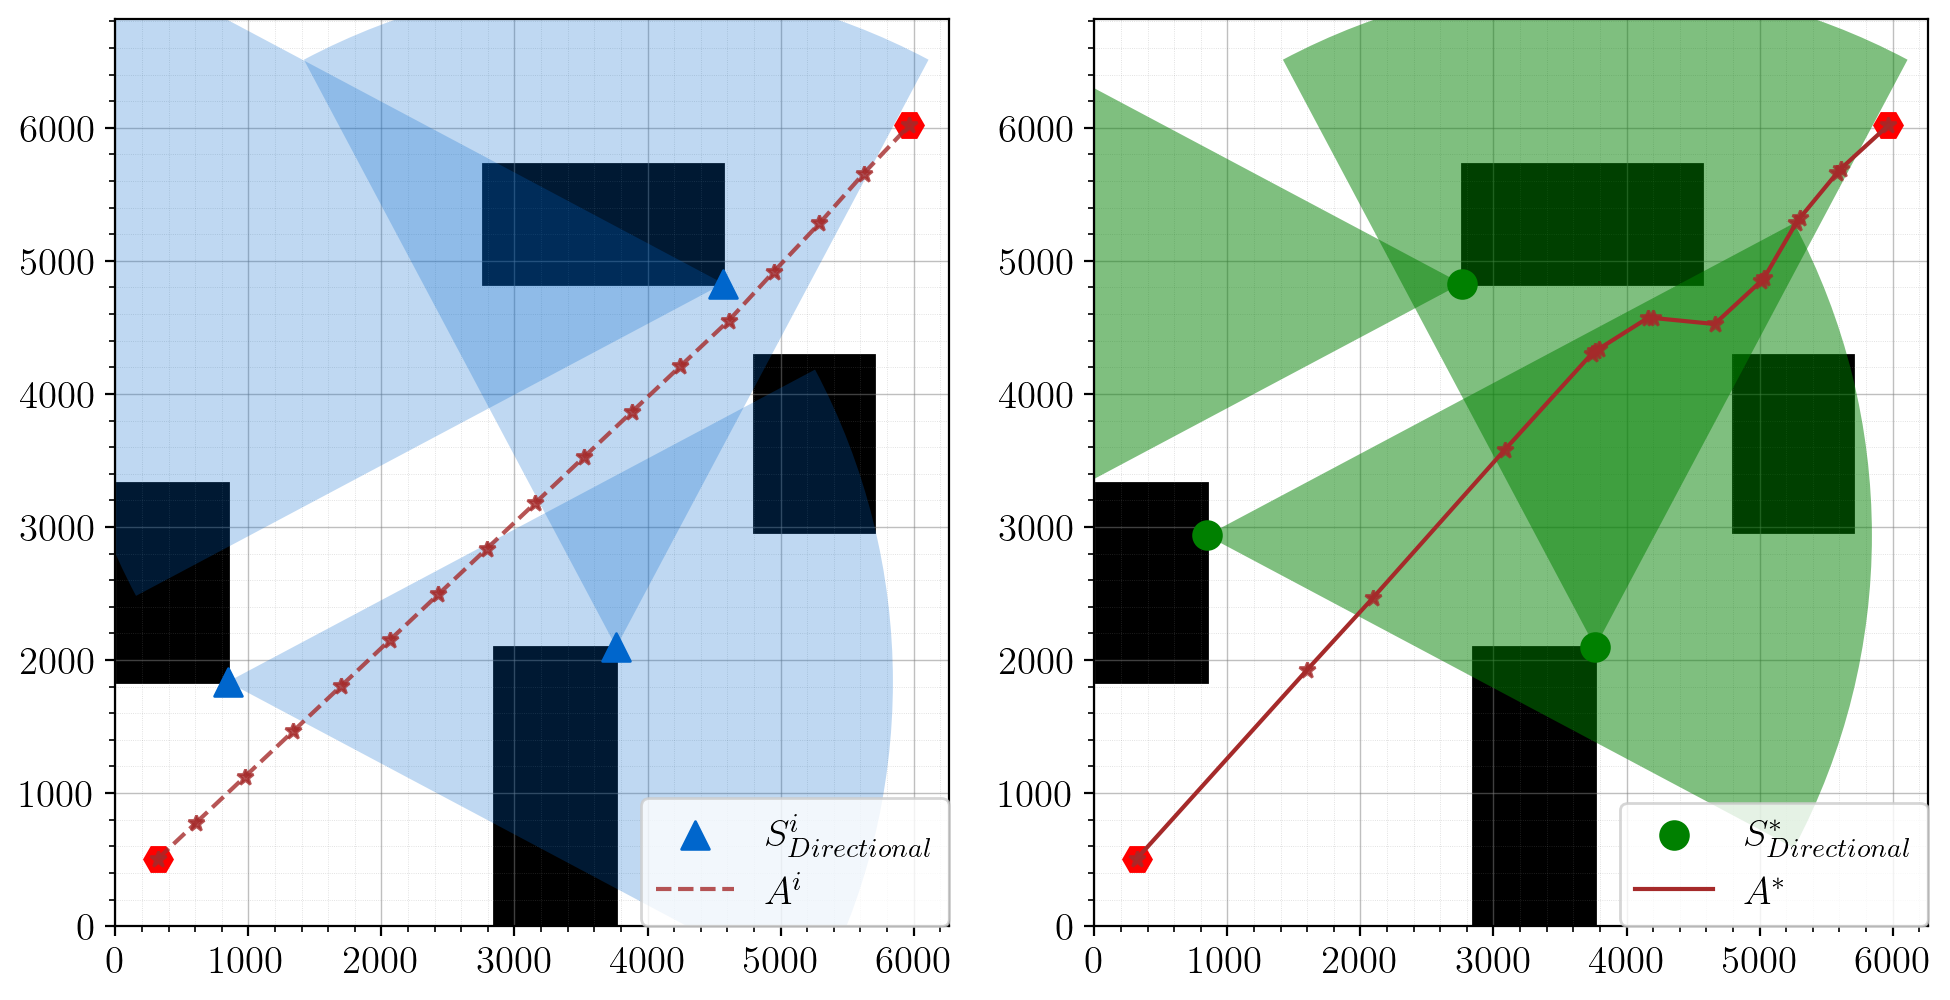

In [44]:
# Plot initial, final path and initial, final setup in a single plot
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True
marker_size_for_sensor = 100

# Start and Goal
x_init = [-252.075, -6456.2]
x_goal = [5399, -940.7]
x0 = [x_init[0] + 569.2,  x_init[1] + 6960,  0.0]
xf = [x_goal[0] + 569.2,  x_goal[1] + 6960,  60.0]
vmax = 500

# Parse Attacker strategy
att_optimal_x = final_waypoints[0]
att_optimal_y = final_waypoints[1]
att_optimal_t = final_waypoints[2]

# Initial Defender strategy
cx_init = np.array(initial_setup[0], dtype=float)
cy_init = np.array(initial_setup[1], dtype=float)

# Parse Defender strategy
def_optimal_x = final_setup[0]
def_optimal_y = final_setup[1]

# ---- Static map bounds & buildings ----
st = map_in["st"]
size = np.array(st["size"], dtype=float)
xmin, xmax, ymin, ymax = size

buildings = []
for i in range(st["n"]):
    poly = np.array(st[str(i)], dtype=float)
    buildings.append(poly)

# ---- Cameras & spec ----
num_direc_sensor = 3
cx_opt = np.array(def_optimal_x[0:num_direc_sensor], dtype=float)
cy_opt = np.array(def_optimal_y[0:num_direc_sensor], dtype=float)
spec = cam_dict['directional']["spec"]
init_angles = np.array(spec["init_angle"], dtype=float)
bound_arr = np.array(spec["bound"], dtype=float)
fov_half = float(spec["fov"][0])
fov_range = float(spec["fov"][1])
panspeeds = np.array(spec["panspeed"], dtype=float)

t = 0
# facings = np.array([
#     _bounce_angle(init_angles[i], bound_arr[i,0], bound_arr[i,1], panspeeds[i], t)
#     for i in range(num_direc_sensor)
# ], dtype=float)
facings = [0, np.pi/2, np.pi]

sensor_alpha = 0.5

fig, (ax_init, ax_opt) = plt.subplots(1, 2, figsize=(10, 8), dpi=200)

for ax in (ax_init, ax_opt):
    # Buildings
    for poly in buildings:
        ax.add_patch(PolyPatch(poly, closed=True, facecolor="black", edgecolor="black", alpha=1.0))
    # Start / Goal
    ax.plot(x0[0], x0[1], 'H', c='r', markersize=10)
    ax.plot(xf[0], xf[1], 'H', c='r', markersize=10)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth='0.3', color='gray', alpha=0.3)

# ==============================================================
# LEFT: Initial strategies
# ==============================================================
# Initial directional sensors
ax_init.scatter(cx_init, cy_init, s=marker_size_for_sensor, color=(0.0, 0.4, 0.8), marker="^", zorder=4, label=r"$S^i_{Directional}$")
# Initial FOV wedges
for i in range(len(cx_init)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx_init[i], cy_init[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor=(0.0, 0.4, 0.8), edgecolor=None,
        alpha=sensor_alpha/2, zorder=2
    )
    ax_init.add_patch(wedge)

# Initial attacker path
# for pi in range(len(initial_waypoint)-1):
#     p0 = initial_waypoint[pi]
#     p1 = initial_waypoint[pi+1]
#     lbl = r"$A^i$" if pi == 0 else None
#     ax_init.plot([p0[0], p1[0]], [p0[1], p1[1]], '--', color='brown', alpha=0.8, label=lbl)

for pi in range(len(initial_waypoint[0])-1):
    lbl = r"$A^i$" if pi == 0 else None
    ax_init.plot([initial_waypoint[0][pi], initial_waypoint[0][pi+1]], [initial_waypoint[1][pi], initial_waypoint[1][pi+1]], '--', color='brown', alpha=0.8, label=lbl)
for pi in range(len(initial_waypoint[0])):
    ax_init.plot(initial_waypoint[0][pi], initial_waypoint[1][pi], '*', color='brown', alpha=0.8, label=lbl)

ax_init.legend(loc='lower right', borderaxespad=0.)
# ax_init.set_title('Initial')

# ==============================================================
# RIGHT: Optimal strategies
# ==============================================================
# Optimal directional sensors
ax_opt.scatter(cx_opt, cy_opt, s=marker_size_for_sensor, c="green", marker="o", zorder=3, label=r"$S^*_{Directional}$")
# Optimal FOV wedges
for i in range(len(cx_opt)):
    theta_deg = math.degrees(facings[i])
    wedge = Wedge(
        center=(cx_opt[i], cy_opt[i]),
        r=fov_range,
        theta1=theta_deg - math.degrees(fov_half),
        theta2=theta_deg + math.degrees(fov_half),
        facecolor="green", edgecolor=None,
        alpha=sensor_alpha, zorder=2
    )
    ax_opt.add_patch(wedge)

# Optimal attacker path
for pi in range(len(att_optimal_x)-1):
    lbl = r"$A^*$" if pi == 0 else None
    ax_opt.plot([att_optimal_x[pi], att_optimal_x[pi+1]],
                [att_optimal_y[pi], att_optimal_y[pi+1]],
                '-', color='brown', label=lbl, zorder=10, linewidth=1.5)
for pi in range(len(final_waypoints[0])):
    ax_opt.plot(final_waypoints[0][pi], final_waypoints[1][pi], '*', color='brown', alpha=0.8, label=lbl)


ax_opt.legend(loc='lower right', borderaxespad=0., fontsize=14)
# ax_opt.set_title('Optimal')

plt.tight_layout()
# fig.savefig('experiment_setup.png', dpi=300, bbox_inches='tight')
fig.savefig('experiment_setup.pdf', dpi=300, bbox_inches='tight')

# Save initial and final waypoints to JSON files
output = {
    "attacker_initial_waypoints": initial_waypoint,
    "defender_initial_setup": initial_setup,
    "attacker_final_waypoints": final_waypoints.tolist(),
    "defender_final_setup": final_setup
}   

with open('processed_results_exp.json', 'w') as f:
    json.dump(output, f, indent=4)